In [71]:
import numpy as np
import matplotlib.pyplot as plt
import flamedisx as fd
import pickle as pkl
import sys
from copy import deepcopy
sys.path.append('../analyses/')
from create_simple_template_likelihood import BasicTemplateSource

In [72]:
with open('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/likelihoods/accidentals/0.1_LNGS_10GeV_updated.pkl', 'rb') as f:
    likelihood_container = pkl.load(f)

print(likelihood_container.expected_background_counts)
print(likelihood_container.gaussian_constraint_widths)

{'SolarER': 11.703523378036506, 'Pb214': 2.2517272886352537, 'Kr85': 10.289086402587893, 'Xe136': 3.848373807861327, 'Xe124': 1.1555721906738277, 'Neutrons': 0.004589858769799771, 'CEvNS_other': 0.0458985876979977, 'CEvNS_solar': 0.9976982437133789, 'accidentals': 0.09999999999999999}
{'SolarER': 0.5430434847408938, 'Pb214': 0.3760384572020874, 'Kr85': 1.7182774292321783, 'Xe136': 0.5772560711791991, 'Xe124': 0.23111443813476554, 'Neutrons': 0.0009179717539599543, 'CEvNS_other': 0.008950224601109552, 'CEvNS_solar': 0.03960862027542114, 'accidentals': 0.005}


In [73]:
print(likelihood_container.expected_signal_counts)
print(likelihood_container.signal_counts_uncertainties)

{'WIMP': 0.0298931876696246}
{}


In [58]:
likelihood_container.__dict__.keys()

dict_keys(['sources', 'arguments', 'batch_size', 'log_constraint', 'expected_signal_counts', 'expected_background_counts', 'gaussian_constraint_widths', 'signal_counts_uncertainties'])

In [59]:
likelihood_container.sources

{'SolarER': create_simple_template_likelihood.BasicTemplateSource,
 'Pb214': create_simple_template_likelihood.BasicTemplateSource,
 'Kr85': create_simple_template_likelihood.BasicTemplateSource,
 'Xe136': create_simple_template_likelihood.BasicTemplateSource,
 'Xe124': create_simple_template_likelihood.BasicTemplateSource,
 'Neutrons': create_simple_template_likelihood.BasicTemplateSource,
 'CEvNS_other': create_simple_template_likelihood.BasicTemplateSource,
 'CEvNS_solar': create_simple_template_likelihood.BasicTemplateSource,
 'accidentals': create_simple_template_likelihood.BasicTemplateSource,
 'WIMP': create_simple_template_likelihood.BasicTemplateSource}

In [60]:
likelihood_container.arguments

{'SolarER': {'template': <multihist.Histdd at 0x7f1d50292010>},
 'Pb214': {'template': <multihist.Histdd at 0x7f1d50277b10>},
 'Kr85': {'template': <multihist.Histdd at 0x7f1d5011a310>},
 'Xe136': {'template': <multihist.Histdd at 0x7f1d502c4b10>},
 'Xe124': {'template': <multihist.Histdd at 0x7f1d5022d4d0>},
 'Neutrons': {'template': <multihist.Histdd at 0x7f1d5022ff10>},
 'CEvNS_other': {'template': <multihist.Histdd at 0x7f1d502e7490>},
 'CEvNS_solar': {'template': <multihist.Histdd at 0x7f1d502e6c90>},
 'accidentals': {'template': <multihist.Histdd at 0x7f1d502e71d0>},
 'WIMP': {'template': <multihist.Histdd at 0x7f1d502e7410>}}

Next, we open the inference config in the way it is used in asymptotic_inference.py to produce the log likelihood.

In [61]:
import configparser

config = configparser.ConfigParser(allow_no_value=True)
config.optionxform = str
with open("/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/inference_configs/inference_config.ini", encoding="utf-8-sig") as f:
    config.read_file(f)


background_sources = list(config["background_sources"].keys())
signal_sources = list(config["signal_sources"].keys())
ntoys = int(config["inference_parameters"]["ntoys"])


background_source_names = background_sources
signal_source_names = signal_sources
print(background_source_names)
print(signal_source_names)

['SolarER', 'Pb214', 'Kr85', 'Xe136', 'Xe124', 'Neutrons', 'CEvNS_other', 'CEvNS_solar', 'accidentals']
['WIMP']


Producing the log likelihood.

In [62]:
sources = dict()
arguments = dict()
for sname, source in likelihood_container.sources.items():
    if (sname == signal_source_names) or (sname in background_source_names):
        sources[sname] = source
        arguments[sname] = likelihood_container.arguments[sname]

print(arguments)
print(sources)

likelihood = fd.LogLikelihood(sources=sources,
                                        arguments=arguments,
                                        batch_size=likelihood_container.batch_size,
                                        free_rates=tuple(sources.keys()),
                                        log_constraint=likelihood_container.log_constraint)


simulated_data = likelihood.simulate(fix_truth=None)
print(simulated_data)
print(np.shape(simulated_data))
print(type(simulated_data))

/global/cfs/cdirs/lz/users/rory_m/flamedisx/flamedisx/source.py:271: UserWarning: Defaults for unused settings ignored: {'max_sigma': None, 'max_sigma_outer': None}
  warnings.warn(f"Defaults for unused settings ignored: {unused}")


{'SolarER': {'template': <multihist.Histdd object at 0x7f1d50292010>}, 'Pb214': {'template': <multihist.Histdd object at 0x7f1d50277b10>}, 'Kr85': {'template': <multihist.Histdd object at 0x7f1d5011a310>}, 'Xe136': {'template': <multihist.Histdd object at 0x7f1d502c4b10>}, 'Xe124': {'template': <multihist.Histdd object at 0x7f1d5022d4d0>}, 'Neutrons': {'template': <multihist.Histdd object at 0x7f1d5022ff10>}, 'CEvNS_other': {'template': <multihist.Histdd object at 0x7f1d502e7490>}, 'CEvNS_solar': {'template': <multihist.Histdd object at 0x7f1d502e6c90>}, 'accidentals': {'template': <multihist.Histdd object at 0x7f1d502e71d0>}}
{'SolarER': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Pb214': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Kr85': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Xe136': <class 'create_simple_template_likelihood.BasicTemplateSource'>, 'Xe124': <class 'create_simple_template_likelihood.BasicTemplateSou

Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]
Estimating mus: 0it [00:00, ?it/s]

         cS1  log10_cS2        radius       source
0   5.117058   2.841074    593.989810  CEvNS_solar
1  21.899703   3.822513  20811.912849        Pb214
2   4.051147   2.623466  12108.335169  accidentals
3  58.070120   3.973833  13710.097822        Xe124
4  33.483602   3.623710  20743.454091     Neutrons
5  13.129286   3.745504   6953.994342        Pb214
6   5.917909   3.364601  17421.815643     Neutrons
7  47.016154   3.910672  20421.766918     Neutrons
8   5.437844   2.750527   1815.521418  CEvNS_solar
9  14.957968   3.534228   4738.422437  CEvNS_other
(10, 4)
<class 'pandas.DataFrame'>


In [63]:
#removing the 'source' column and using set_data()
df = simulated_data.iloc[:, :-1]
print(df)
print(np.shape(df))
likelihood.set_data(df)


         cS1  log10_cS2        radius
0   5.117058   2.841074    593.989810
1  21.899703   3.822513  20811.912849
2   4.051147   2.623466  12108.335169
3  58.070120   3.973833  13710.097822
4  33.483602   3.623710  20743.454091
5  13.129286   3.745504   6953.994342
6   5.917909   3.364601  17421.815643
7  47.016154   3.910672  20421.766918
8   5.437844   2.750527   1815.521418
9  14.957968   3.534228   4738.422437
(10, 3)


Finding the value of the mu estimators.

In [64]:
for sname, mu in likelihood.mu_estimators.items():
 print(sname, mu())

SolarER tf.Tensor(1.0, shape=(), dtype=float32)
Pb214 tf.Tensor(1.0, shape=(), dtype=float32)
Kr85 tf.Tensor(1.0, shape=(), dtype=float32)
Xe136 tf.Tensor(1.0, shape=(), dtype=float32)
Xe124 tf.Tensor(1.0, shape=(), dtype=float32)
Neutrons tf.Tensor(1.0, shape=(), dtype=float32)
CEvNS_other tf.Tensor(1.0, shape=(), dtype=float32)
CEvNS_solar tf.Tensor(1.0, shape=(), dtype=float32)
accidentals tf.Tensor(1.0, shape=(), dtype=float32)


Our mu_estimators are equal to 1, so our expected no. of counts are equal to the rate multiplier.

In [ ]:
import scipy.stats as stats
from tqdm import tqdm

means, sigmas, param_names = [], [], []

expected_background_counts = likelihood_container.expected_background_counts
gaussian_constraint_widths = likelihood_container.gaussian_constraint_widths


sources_remove = []
fix_dict = {}

#Applying a constraint on our likelihood

constraint_extra_args = dict()
for background_source, counts in expected_background_counts.items():
    constraint_extra_args[f'{background_source}_expected_counts'] = counts

likelihood.set_constraint_extra_args(**constraint_extra_args)



for k,v in expected_background_counts.items():
    
    if k in sources_remove:
        continue
    if k not in gaussian_constraint_widths:
        print(k)
        continue
    
    means.append(v)
    sigmas.append(gaussian_constraint_widths[k])

    param_names.append(k+'_rate_multiplier')
means = np.array(means)
sigmas = np.array(sigmas)
print(param_names)
nuisance_param_sampler = stats.multivariate_normal(mean=means, cov=np.diag(np.square(sigmas)), allow_singular=True) #sampling nuissance parameters from our likelihood container values. One distribtuion per source.


def get_pulls(toys=1000):
    pulls = {k: [] for k in param_names}    #creating empty sets for each source in param_names
    MLEs = {k: [] for k in param_names}
    stds = {k: [] for k in param_names}
    true = {k: [] for k in param_names}
    this_likelihood = deepcopy(likelihood)  #deepcopy creates a copy of the likelihood without changing the original likelihood
    chi2_values = [] 
    ll_values = []
    for i in tqdm(range(toys)):
        sample = nuisance_param_sampler.rvs()   #generates a random sample from the gaussian distributions
        toy_simulate_dict = dict()
        for j, name in enumerate(param_names):
            if sample[j] < 0:
                sample[j] = 0.0
            toy_simulate_dict[name] = sample[j]


        # Generate toy data
        toy_data = this_likelihood.simulate(**toy_simulate_dict) #(**toy_simlate_dict) is of the form (<source1> = 1.23587, <source2> = 6.0925) etc.
        toy_data = toy_data.iloc[:, :-1] #removing the source name column from our simulated dataset
        this_likelihood.set_data(toy_data)


        # try:

        bestfit = this_likelihood.bestfit(guess=toy_simulate_dict, fix=fix_dict)        #returns the best fit for each source

        # except:                                                                             #Getting rid of the case where the best fit doesn't work
        #     bestfit = {k:np.nan for k in this_likelihood.param_defaults.keys()}
        #     print(bestfit)
        # Get the uncertainties
        cov = 2. * this_likelihood.inverse_hessian(bestfit, omit_grads=tuple(fix_dict.keys())) #the covariance matrix of the maximum likelihood estimator
        list_std_errs = np.diag(cov) ** 0.5
        corr = cov * np.outer(1 / list_std_errs, 1 / list_std_errs)
        std_errs = dict()
        for i, name in enumerate(bestfit):
            if name in fix_dict:
                continue
            std_errs[name] = list_std_errs[i]
        
        for component in bestfit.keys():
            if component not in pulls:
                continue
            pulls[component].append((bestfit[component] - toy_simulate_dict[component]) / std_errs[component])
            MLEs[component].append(bestfit[component])
            stds[component].append(std_errs[component])
            true[component].append(toy_simulate_dict[component])
    return pulls,MLEs,stds,true

WIMP
[]


ValueError: zero-size array to reduction operation maximum which has no identity

In [66]:
pulls, MLEs, stds, true = get_pulls()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [04:24<00:00,  3.78it/s]


In [67]:
background_name = 'accidentals'

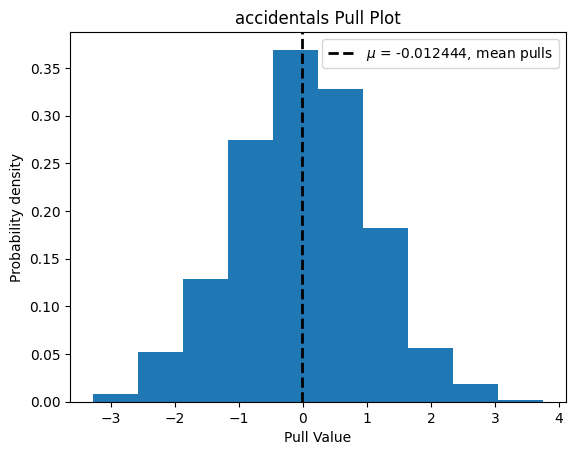

In [68]:
#print(pulls['Neutrons_rate_multiplier'])
mean_pulls = np.mean(pulls[f'{background_name}_rate_multiplier'])
plt.hist(pulls[f'{background_name}_rate_multiplier'], density=true)
plt.title(f'{background_name} Pull Plot')
plt.ylabel('Probability density')
plt.xlabel('Pull Value')
plt.axvline(x=mean_pulls, color='k', linestyle='--', linewidth=2, label=f'$\mu$ = {mean_pulls:2f}, mean pulls')
plt.legend()
plt.show()

In [69]:
mean_fit = np.mean(MLEs[f'{background_name}_rate_multiplier'])
std_fit = np.mean(stds[f'{background_name}_rate_multiplier'])
print(mean_fit, 'Best fit number')
print(std_fit, 'Error on best fit number')

print(likelihood_container.expected_background_counts[background_name], 'Pre-fit expected number')
print(likelihood_container.gaussian_constraint_widths[background_name], 'Error on pre-fit number')


0.10000157813042754 Best fit number
0.004999513844527502 Error on best fit number
0.09999999999999999 Pre-fit expected number
0.005 Error on pre-fit number


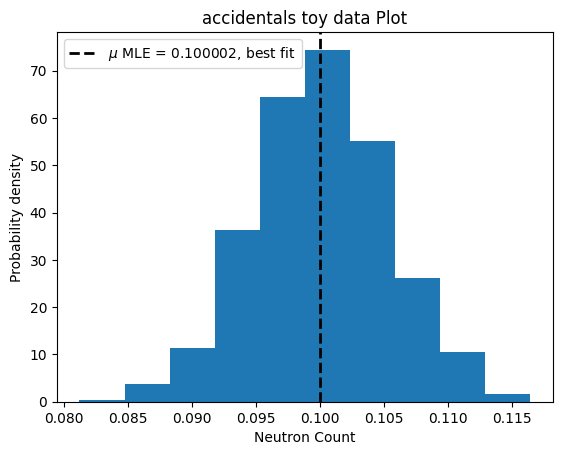

In [70]:
# Toy data distribution

plt.hist(true[f'{background_name}_rate_multiplier'], density=true)
plt.title(f'{background_name} toy data Plot')
plt.ylabel('Probability density')
plt.xlabel('Neutron Count')
plt.axvline(x=mean_fit, color='k', linestyle='--', linewidth=2, label=f'$\mu$ MLE = {mean_fit:2f}, best fit')
plt.legend()
plt.show()